Questo codice racchiude i seguenti esperimenti:


*   Train synth - test ped2
*   Train synth - test dataset sintetico
*   Train synth - test MED

Per il train abbiamo utilizzato l'80% dei video normali del dataset sintetico, ovvero 114.



In [ ]:
import os
from pathlib import Path
import shutil
import re
import time

import cv2
from PIL import Image

import numpy as np
from scipy.io import savemat, loadmat
import scipy.io as sio
import pandas as pd

import torch

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import seaborn as sns



#1-🛠️Clonazione github e connessione a drive per reperire i frames

In [ ]:
%cd /content
!rm -rf astnet #Pulizia
!git clone https://github.com/marco-caruso/astnet.git
%cd astnet


/content
Cloning into 'astnet'...
remote: Enumerating objects: 799, done.
remote: Counting objects: 100% (232/232), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 799 (delta 189), reused 63 (delta 63), pack-reused 567 (from 1)
Receiving objects: 100% (799/799), 45.15 MiB | 40.34 MiB/s, done.
Resolving deltas: 100% (449/449), done.
/content/astnet


In [ ]:
# Installazione requirements dalla root come richiesto dal README astnet
!pip install -r requirements.txt

ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.21.5 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.22.2, 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#2-🔗Creazione dei symlink/Copia dei file da drive

Questo processo serve per fornire i frame (presenti su drive)  alla rete nella struttura che si aspetta

##2.1-Ped2

In [ ]:
#!mkdir -p "/content/astnet/data/ped2/training"
!mkdir -p "/content/astnet/data/ped2/testing"



Creazione dei symlink

In [ ]:
'''
!ln -s "/content/drive/MyDrive/datasets/ped2/training/frames" \
      "/content/astnet/data/ped2/training/frames"
'''

!ln -s "/content/drive/MyDrive/datasets/ped2/testing/frames" \
      "/content/astnet/data/ped2/testing/frames"

!ln -s "/content/drive/MyDrive/datasets/ped2/ped2.mat" \
      "/content/astnet/data/ped2/ped2.mat"


Verifica

In [ ]:
!ls /content/astnet/data/ped2
#!ls /content/astnet/data/ped2/training/frames
!ls /content/astnet/data/ped2/testing/frames


ped2.mat  testing  training
01  02	03  04	05  06	07  08	09  10	11  12	13  14	15  16
01  02	03  04	05  06	07  08	09  10	11  12


##2.2-Synth

In [ ]:
#!mkdir -p "/content/astnet/data/synth/training"
!mkdir -p "/content/astnet/data/synth/testing"

Copia dei frames in locale per velocizzare il testing

In [ ]:
'''
print("Inizio copia dei frame di training:")
!cp -r "/content/drive/MyDrive/datasets/Synth/split_80-20-20_astnet/training/frames" \
      "/content/astnet/data/synth/training/frames/"
print("Fine copia dei frame di training.")
'''

print("Inizio copia dei frame di testing:")
!cp -r "/content/drive/MyDrive/datasets/Synth/split_80-20-20_astnet/testing/frames" \
      "/content/astnet/data/synth/testing/frames/"
print("Fine copia dei frame di testing.")

print("Copia del file .mat.")
!cp "/content/drive/MyDrive/datasets/Synth/split_80-20-20_astnet/synth.mat" \
    "/content/astnet/data/synth/synth.mat"

print("Finito")


Inizio copia dei frame di testing:
Fine copia dei frame di testing.
Copia del file .mat.
Finito


Verifica

In [ ]:
!ls /content/astnet/data/synth
#!ls /content/astnet/data/synth/training/frames
!ls /content/astnet/data/synth/testing/frames

synth.mat  testing
auto_0001      caos_0007   fight_0035  n_0033  n_0083  n_0119  n_0139
auto_0003      caos_0008   fight_0036  n_0039  n_0085  n_0120  violence_0001
backpack_0001  caos_0017   fight_0042  n_0040  n_0095  n_0125  violence_0003
backpack_0002  caos_0020   fire_0001   n_0043  n_0096  n_0128  violence_0005
backpack_0003  fight_0002  fire_0004   n_0062  n_0101  n_0129  violence_0010
backpack_0014  fight_0013  n_0002      n_0064  n_0105  n_0130  weapons_0009
backpack_0018  fight_0015  n_0019      n_0067  n_0106  n_0132  weapons_0011
caos_0003      fight_0027  n_0031      n_0075  n_0114  n_0135  weapons_0014


##2.3-MED

Per questo dataset, invece di creare collegamenti simbolici (symlink), si è scelto di effettuare una copia fisica dei frame direttamente su Colab.
Questa scelta è motivata dal fatto che l'elevato numero di file coinvolti rende l'uso dei symlink inefficiente, causando rallentamenti significativi durante l'accesso ai dati e le operazioni di testing.

In [ ]:
!mkdir -p "/content/astnet/data/med/testing"

In [ ]:
print("Inizio copia dei frame:")
!cp -r "/content/drive/MyDrive/datasets/med/testing/frames" "/content/astnet/data/med/testing/frames"

print("Copia del file ground truth...")
!cp "/content/drive/MyDrive/datasets/med/med.mat" "/content/astnet/data/med/med.mat"

print("Finito")

Inizio copia dei frame:
Copia del file ground truth...
Finito


#3-⚙️Training

##3.1-Synth

Nel file synth.yaml è stato impostato un frame_steps=5 (rispetto al valore di default "2") per ottimizzare l'efficienza computazionale. Questa scelta ha permesso di abbattere i tempi di training del dataset sintetico, riducendo la ridondanza temporale dei frame e accelerando la convergenza del modello.

###Training da zero

Questo codice serve per trainare il modello da zero su .synth.

In [ ]:
%cd /content/astnet/ASTNet
!perl -pi -e 's/\bnp\.float\b/float/g; s/\bnp\.int\b/int/g; s/\bnp\.bool\b/bool/g; s/\bnp\.object\b/object/g' utils/anomaly_util.py

/content/astnet/ASTNet


In [ ]:
!pip install yacs

Copiamo i pesi da drive

In [ ]:
# Crea la cartella
!mkdir -p /content/astnet/ASTNet/datasets/seg_weights/

# Copia il file da Drive (se lo avevi salvato lì)
!cp /content/drive/MyDrive/datasets/weights/wider_resnet38.pth /content/astnet/ASTNet/datasets/seg_weights/

Copiamo l'ultima epoca da cui far ripartire il training (checkpoint)

In [ ]:
!mkdir -p /content/astnet/ASTNet/output/synth/synth_wresnet/
!cp /content/drive/MyDrive/datasets/Training_Backup/epoch_40.pth /content/astnet/ASTNet/output/synth/synth_wresnet/epoch_40.pth

In [ ]:
#!cd /content/astnet/ASTNet/
#!python train.py --cfg config/synth_wresnet.yaml
!python /content/astnet/ASTNet/train.py --cfg /content/astnet/ASTNet/config/synth_wresnet.yaml
#!python /content/astnet/ASTNet/train.py --cfg /content/astnet/ASTNet/config/synth_wresnet.yaml TRAIN.RESUME True TRAIN.CHECKPOINT /content/astnet/ASTNet/output/synth/synth_wresnet/epoch_10.pth TRAIN.BEGIN_EPOCH 10





=> creating output/synth/synth_wresnet
=> creating log/synth/wrn38/synth_wresnet_2026-02-04-00-12
Namespace(cfg='/content/astnet/ASTNet/config/synth_wresnet.yaml', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 4, 'PRINT_FREQ': 20, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/astnet/data/', 'DATASET': 'synth', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 5, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 4, 'SHUFFLE': True, 'BEGIN_EPOCH': 40, 'END_EPOCH': 50, 'RESUME': True, 'CHECKPOINT': '/content/astnet/ASTNet/output/synth/synth_wresnet/epoch_40.pth', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 5e-05, 'LR_STEP': [], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_SIZE_PER_GPU': 1

In [ ]:
from google.colab import files
files.download('/content/astnet/ASTNet/output/synth/synth_wresnet/epoch_30.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!cp '/content/astnet/ASTNet/output/synth/synth_wresnet/epoch_50.pth' '/content/drive/MyDrive/datasets/Training_Backup'

In [ ]:
!cp '/content/drive/MyDrive/datasets/Training_Backup/' '/content/astnet/ASTNet/output/synth/synth_wresnet/epoch_50.pth'

cp: -r not specified; omitting directory '/content/drive/MyDrive/datasets/Training_Backup/'


###Recap del training e copia del file .pth in locale per il testing

Il modello impara a ricostruire esclusivamente scene normali per minimizzare la Total Loss. In fase di test, la presenza di un'anomalia (mai vista prima) impedirà una ricostruzione corretta, causando un crollo del PSNR che segnalerà così l'evento sospetto.

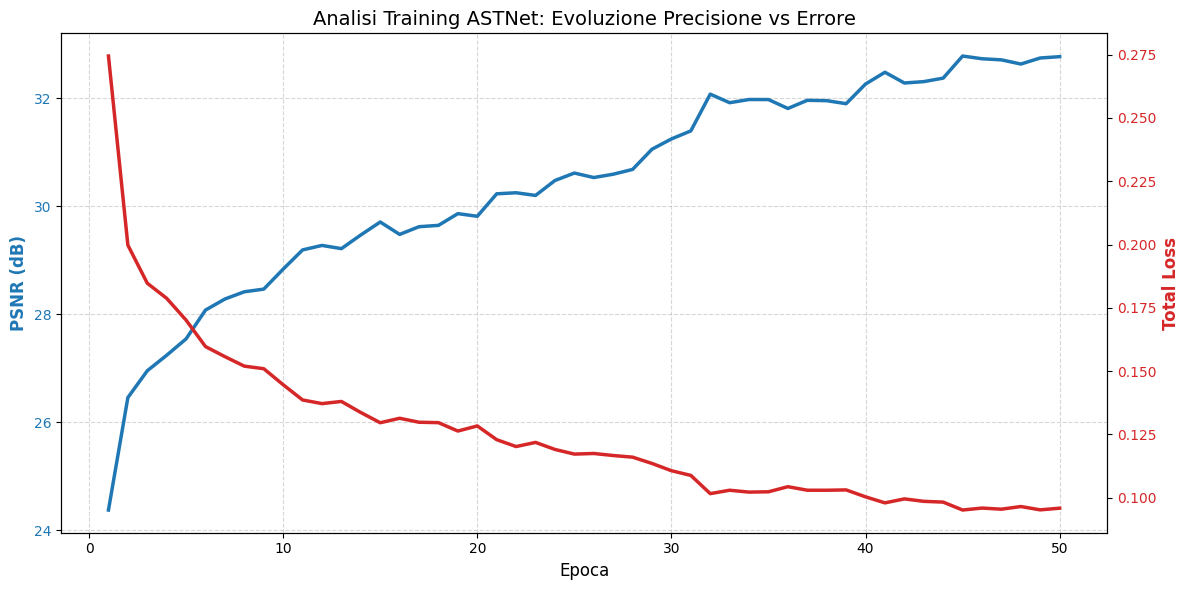

In [ ]:

log_files = [
    "/content/drive/MyDrive/datasets/Training_Backup/[1-10]synth_wresnet_2026-01-31-12-21_train.log",
    "/content/drive/MyDrive/datasets/Training_Backup/[11-20]synth_wresnet_2026-02-01-12-16_train.log",
    "/content/drive/MyDrive/datasets/Training_Backup/[21-30]synth_wresnet_2026-02-02-09-34_train.log",
    "/content/drive/MyDrive/datasets/Training_Backup/[31-40]synth_wresnet_2026-02-03train.txt",
    "/content/drive/MyDrive/datasets/Training_Backup/[41-50]synth_wresnet_2026-02-03train.txt"
]

def plot_training_results(files):
    data = []
    # Pattern per catturare Epoca, le 4 componenti della Loss e il PSNR
    pattern = re.compile(r"Epoch: \[(\d+)\]\[\d+/\d+\].*?inte ([\d\.]+) \+ grad ([\d\.]+) \+ msssim ([\d\.]+) \+ L2 ([\d\.]+)\].*?PSNR ([\d\.]+)")

    for f_path in files:
        with open(f_path, 'r') as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    epoch = int(match.group(1))
                    # Loss Totale = somma delle 4 componenti
                    total_loss = float(match.group(2)) + float(match.group(3)) + \
                                 float(match.group(4)) + float(match.group(5))
                    psnr = float(match.group(6))
                    data.append({'Epoch': epoch, 'Loss': total_loss, 'PSNR': psnr})

    if not data:
        print("Nessun dato trovato. Controlla i percorsi dei file.")
        return

    # Tabella e calcolo media per epoca
    df = pd.DataFrame(data).groupby('Epoch').mean().reset_index()

    # Grafico
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Blu: PSNR (asse sinistro)
    ax1.set_xlabel('Epoca', fontsize=12)
    ax1.set_ylabel('PSNR (dB)', color='tab:blue', fontsize=12, fontweight='bold')
    ax1.plot(df['Epoch'], df['PSNR'], color='tab:blue', label='PSNR (Qualità)', linewidth=2.5)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Rosso: Total Loss (asse destro)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Total Loss', color='tab:red', fontsize=12, fontweight='bold')
    ax2.plot(df['Epoch'], df['Loss'], color='tab:red', label='Loss (Errore)', linewidth=2.5)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    plt.title('Analisi Training ASTNet: Evoluzione Precisione vs Errore', fontsize=14)
    fig.tight_layout()
    plt.show()


plot_training_results(log_files)

###Copia in locale del modello trainato con 50 epoche

In [ ]:
!cp /content/drive/MyDrive/datasets/Training_Backup/epoch_15.pth /content/astnet/ASTNet/epoch_15.pth

print("File copiato con successo!")

File copiato con successo!


#4-📝Testing

Operazioni preliminari per evitare errori di tipo

In [ ]:
%cd /content/astnet/ASTNet
!perl -pi -e 's/\bnp\.float\b/float/g; s/\bnp\.int\b/int/g; s/\bnp\.bool\b/bool/g; s/\bnp\.object\b/object/g' utils/anomaly_util.py

/content/astnet/ASTNet


In [ ]:
!pip install yacs

**A causa dell'utilizzo di una finestra temporale di input pari a 4 frame, impostata nei file di configurazione .yaml, il modello non è in grado di generare predizioni per i frame iniziali di ciascun video, che vengono esclusi dalla fase di valutazione.

##4.1-Test ped2

* train: synth con 50 epoche (114 video)
* test: ped2 (12 video)

Frame totali utilizzati nel test: 1962

In [ ]:
%cd /content/astnet/ASTNet
!python test.py \
  --cfg config/ped2_wresnet.yaml \
  --model-file epoch_15.pth

/content/astnet/ASTNet
=> creating output
=> creating output/ped2/ped2_wresnet
=> creating log/ped2/wrn38/ped2_wresnet_2026-02-06-10-45
Namespace(cfg='config/ped2_wresnet.yaml', model_file='epoch_15.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 2, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/drive/MyDrive/datasets', 'DATASET': 'ped2', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 5, 'LOWER_BOUND': 100}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 120, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [80, 100], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_SIZE_PER_GPU': 1}),

Salvataggio del test su drive

In [ ]:
!cp -r /content/astnet/ASTNet/output/ped2 /content/drive/MyDrive/datasets/ASTNet_results/train_with_synth

##4.2-Test synth

* train: synth con 50 epoche (114 video)
* test: synth (56 video = 28 video normali + 28 video anomali)

Suddvisione anomalie nel dataset sintetico:


*   auto: 2 video
*   backpack: 5 video
*   caos: 5 video
*   fight: 7 video
*   fire: 2 video
*   violence: 4 video
*   weapons: 3 video

Frame totali utilizzati nel test: (243-4)*56 = 13384

In [ ]:
%cd /content/astnet/ASTNet

!python test.py \
  --cfg config/synth_wresnet.yaml \
  --model-file epoch_15.pth



/content/astnet/ASTNet
=> creating output
=> creating output/synth/synth_wresnet
=> creating log/synth/wrn38/synth_wresnet_2026-02-06-11-17
Namespace(cfg='config/synth_wresnet.yaml', model_file='epoch_15.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 2, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/astnet/data/', 'DATASET': 'synth', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 5, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 4, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 50, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [30, 40], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_SIZE_PER_GPU': 1}), 'MODEL'

Salvataggio del test su drive

In [ ]:
!cp -r /content/astnet/ASTNet/output/synth /content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/

##4.3-Test MED

In [ ]:
%cd /content/astnet/ASTNet
!python test.py \
  --cfg config/med_wresnet.yaml \
  --model-file epoch_50.pth

/content/astnet/ASTNet
=> creating output/med/med_wresnet
=> creating log/med/wrn38/med_wresnet_2026-02-05-14-58
Namespace(cfg='config/med_wresnet.yaml', model_file='epoch_50.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 2, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/astnet/data/', 'DATASET': 'med', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 5, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 120, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [80, 100], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_SIZE_PER_GPU': 1}), 'MODEL': CfgNode({'NAME': 'wrn38', '

In [ ]:
!cp -r /content/astnet/ASTNet/output/med /content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/

#5-📈Results

##5.1 Ped2

###Plot

Soglia globale ottimale (Youden) per Ped2: 0.2976
Numero totale di video trovati: 12


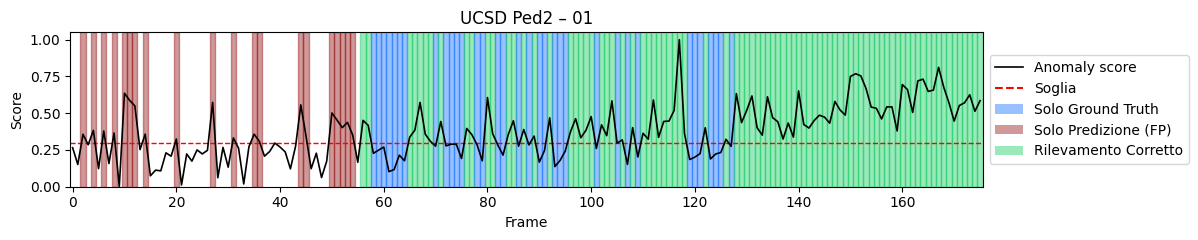

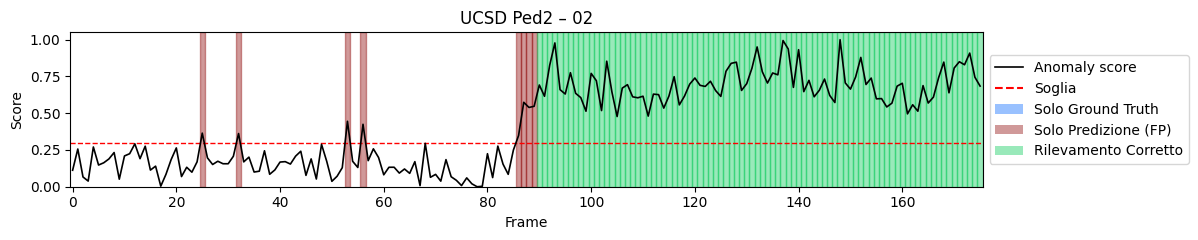

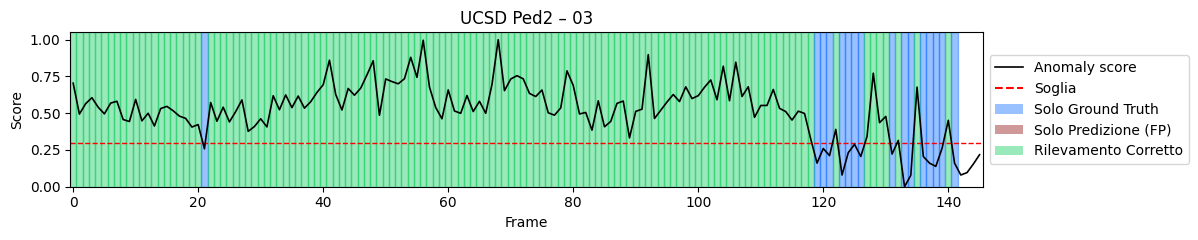

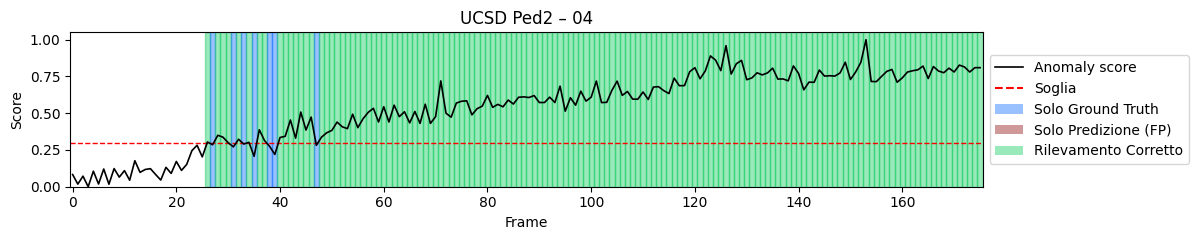

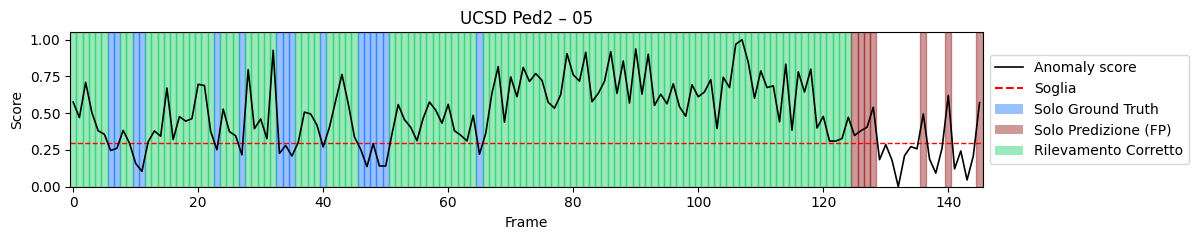

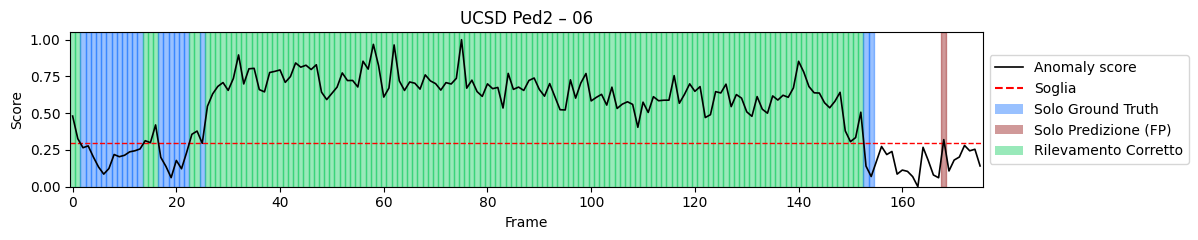

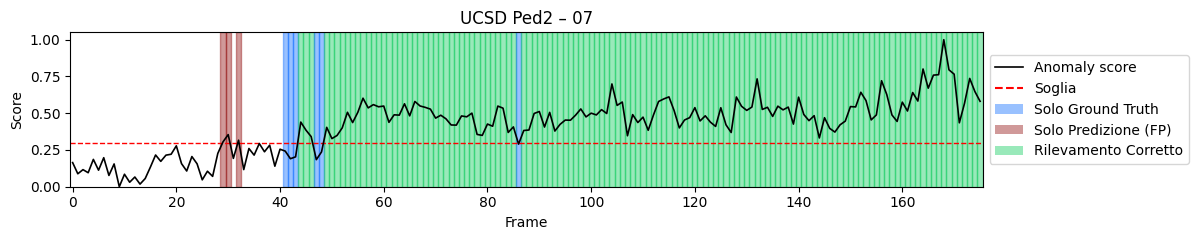

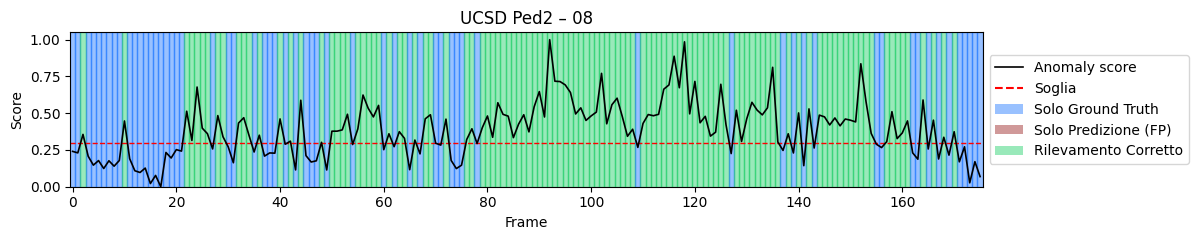

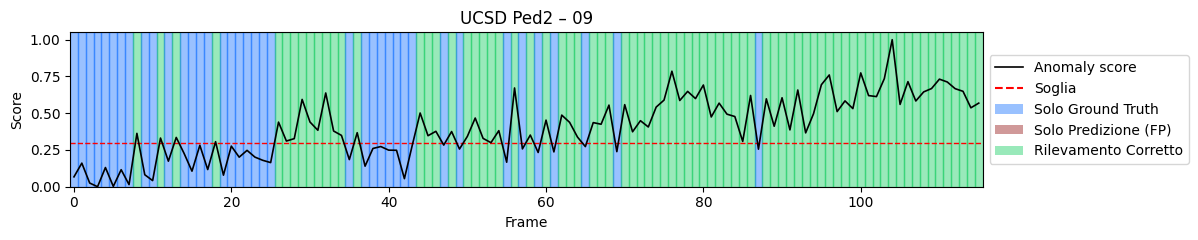

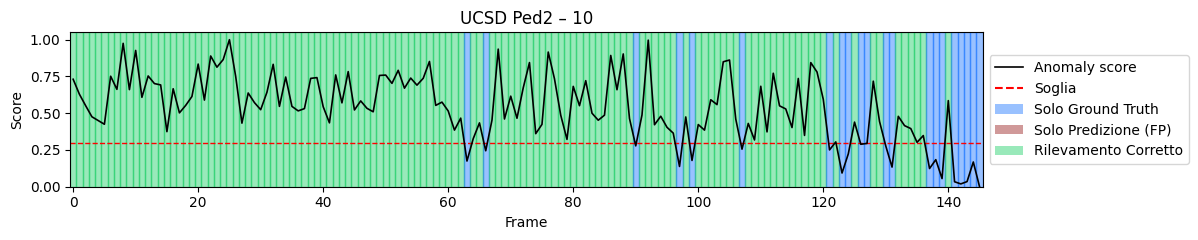

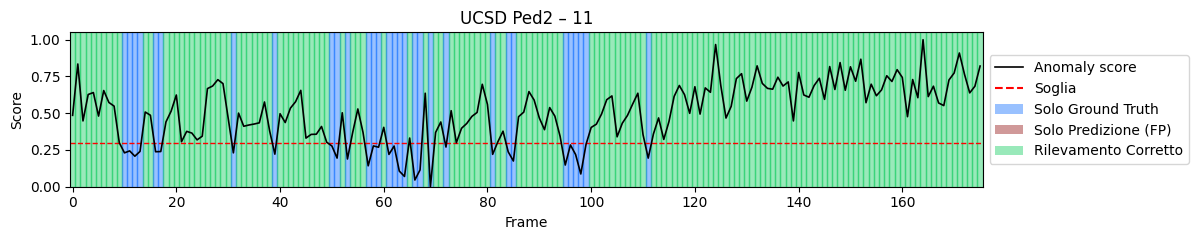

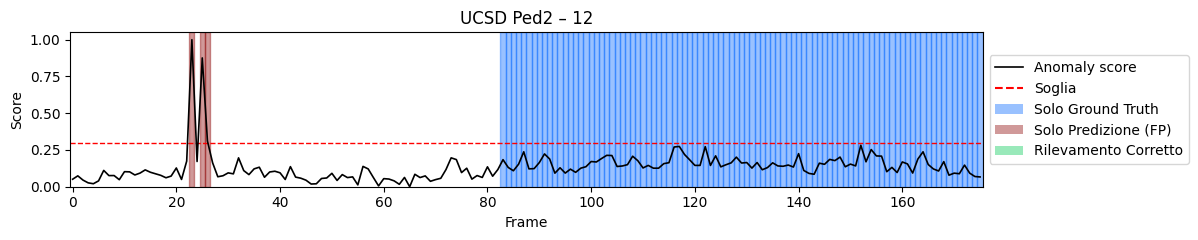

In [ ]:

OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/ped2/ped2_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/ped2/testing/frames")

# Caricamento dei dati dai file .npy generati dal test
try:
    psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)
except FileNotFoundError:
    psnr_list = np.load(OUT_DIR / "psnr.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt.npy", allow_pickle=True)

# Recupero nomi delle cartelle video
video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames


# Score continuo
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    # Normalizzazione Min-Max invertita (PSNR basso = Score alto)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)
    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]
print(f"Soglia globale ottimale (Youden) per Ped2: {best_thr:.4f}")

#-------
# Plot
#-------
def plot_video_ped2(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    # Gestione nome video
    name = video_names[idx] if idx < len(video_names) else f"Video {idx+1}"

    colors = np.empty(L, dtype=object)
    colors[:] = 'none'

    # Blu: Anomalia reale non vista (False Negative)
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'
    # Rosso: Allarme dove non c'è anomalia (False Positive)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'
    # Verde: Anomalia rilevata correttamente (True Positive)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=1, label='Soglia', zorder=2)

    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.4, zorder=1)

    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Soglia'),
        Patch(facecolor='#0066FF', alpha=0.4, label='Solo Ground Truth'),
        Patch(facecolor='#8B0000', alpha=0.4, label='Solo Predizione (FP)'),
        Patch(facecolor='#00C853', alpha=0.4, label='Rilevamento Corretto')
    ]

    ax.set_title(f"UCSD Ped2 – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Esecuzione finale
num_videos = len(psnr_list)
print(f"Numero totale di video trovati: {num_videos}")

for i in range(num_videos):
    plot_video_ped2(i)

###ROC curve

Nota sulla valutazione

I risultati mostrati in questo notebook (AUC = 89.1%) sono stati ottenuti
utilizzando frame_steps = 2.

Nei log dell'esperimento è presente anche una valutazione eseguita con
frame_steps = 5, che produce AUC = 91.8%.

La differenza tra i due valori è dovuta al diverso stride temporale utilizzato
durante il test.
Il valore riportato nella tesi si riferisce alla prima esecuzione della
valutazione.

N video psnr: 12
N video gt: 12
AUC complessiva (MED): 89.1%


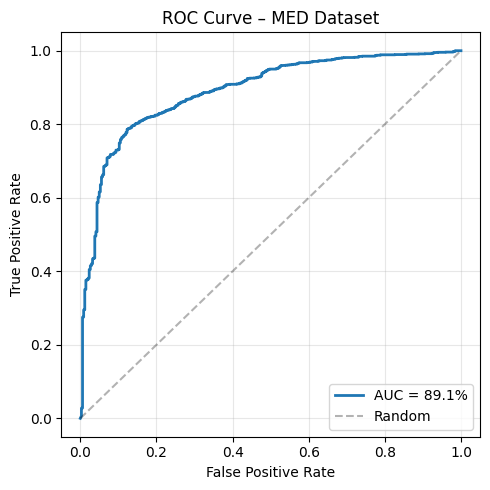

In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/ped2/ped2_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (PED2): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – PED2 Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion matrix

Soglia ottimale (Youden): 0.2976

=== METRICHE MED ===
Accuracy:  80.22%
Precision: 96.81%
Recall:    78.64%
F1-Score:  86.78%

Matrice di Confusione:
[[ 300   42]
 [ 346 1274]]


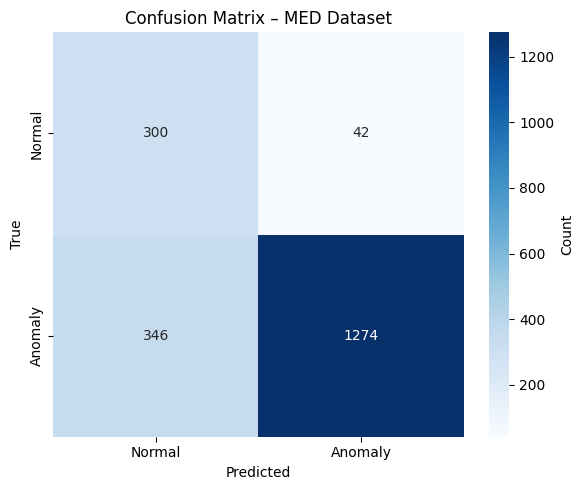


Dettagli:
True Negatives:  300
False Positives: 42
False Negatives: 346
True Positives:  1274


In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/ped2/ped2_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE PED2 ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Ped2 Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

##5.2 Synth

###Plot

In [ ]:

OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/synth/synth_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/Synth/split_80-20-20_astnet/testing/frames")

# Caricamento dei dati dai file .npy generati dal test
try:
    psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)
except FileNotFoundError:
    psnr_list = np.load(OUT_DIR / "psnr.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt.npy", allow_pickle=True)

# Recupero nomi delle cartelle video
video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames


# Score continuo
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    # Normalizzazione Min-Max invertita (PSNR basso = Score alto)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)
    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]
print(f"Soglia globale ottimale (Youden) per Ped2: {best_thr:.4f}")

#-------
# Plot
#-------
def plot_video_ped2(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    # Gestione nome video
    name = video_names[idx] if idx < len(video_names) else f"Video {idx+1}"

    colors = np.empty(L, dtype=object)
    colors[:] = 'none'

    # Blu: Anomalia reale non vista (False Negative)
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'
    # Rosso: Allarme dove non c'è anomalia (False Positive)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'
    # Verde: Anomalia rilevata correttamente (True Positive)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=1, label='Soglia', zorder=2)

    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.4, zorder=1)

    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Soglia'),
        Patch(facecolor='#0066FF', alpha=0.4, label='Solo Ground Truth'),
        Patch(facecolor='#8B0000', alpha=0.4, label='Solo Predizione (FP)'),
        Patch(facecolor='#00C853', alpha=0.4, label='Rilevamento Corretto')
    ]

    ax.set_title(f"Synth – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Esecuzione finale
num_videos = len(psnr_list)
print(f"Numero totale di video trovati: {num_videos}")

for i in range(num_videos):
    plot_video_ped2(i)

Output hidden; open in https://colab.research.google.com to view.

###ROC curve

N video psnr: 56
N video gt: 56
AUC complessiva (synth): 54.6%


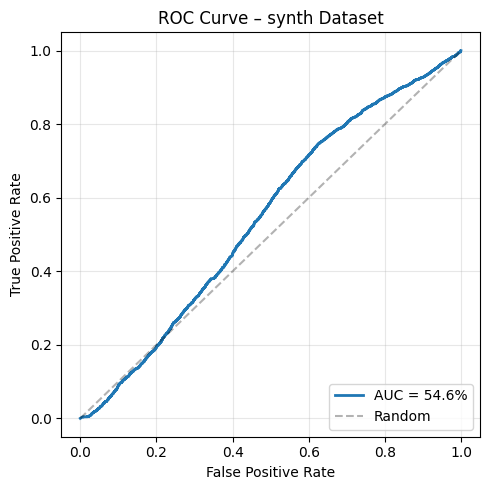

In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/synth/synth_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (synth): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – synth Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion matrix

Soglia ottimale (Youden): 0.2139

=== METRICHE SYNTH ===
Accuracy:  46.17%
Precision: 26.51%
Recall:    74.58%
F1-Score:  39.12%

Matrice di Confusione:
[[3864 6416]
 [ 789 2315]]


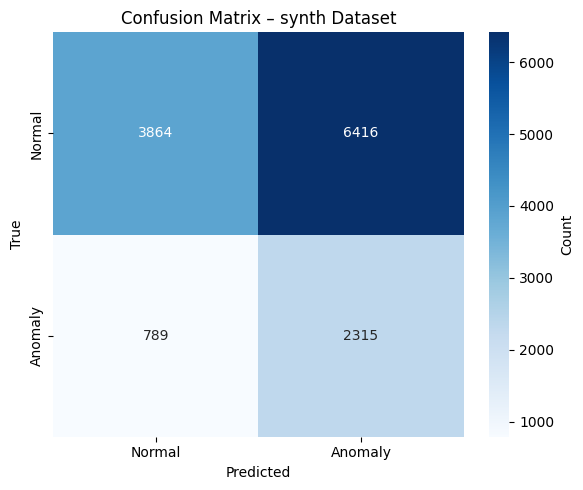


Dettagli:
True Negatives:  3864
False Positives: 6416
False Negatives: 789
True Positives:  2315


In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/synth/synth_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE SYNTH ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – synth Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

##5.3 MED

###Plot

In [ ]:

OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/med/med_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/med/testing/frames")

# Caricamento dei dati dai file .npy generati dal test
try:
    psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)
except FileNotFoundError:
    psnr_list = np.load(OUT_DIR / "psnr.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt.npy", allow_pickle=True)

# Recupero nomi delle cartelle video
video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames


# Score continuo
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    # Normalizzazione Min-Max invertita (PSNR basso = Score alto)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)
    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]
print(f"Soglia globale ottimale (Youden) per MED: {best_thr:.4f}")

#-------
# Plot
#-------
def plot_video_ped2(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    # Gestione nome video
    name = video_names[idx] if idx < len(video_names) else f"Video {idx+1}"

    colors = np.empty(L, dtype=object)
    colors[:] = 'none'

    # Blu: Anomalia reale non vista (False Negative)
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'
    # Rosso: Allarme dove non c'è anomalia (False Positive)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'
    # Verde: Anomalia rilevata correttamente (True Positive)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=1, label='Soglia', zorder=2)

    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.4, zorder=1)

    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Soglia'),
        Patch(facecolor='#0066FF', alpha=0.4, label='Solo Ground Truth'),
        Patch(facecolor='#8B0000', alpha=0.4, label='Solo Predizione (FP)'),
        Patch(facecolor='#00C853', alpha=0.4, label='Rilevamento Corretto')
    ]

    ax.set_title(f"MED – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Esecuzione finale
num_videos = len(psnr_list)
print(f"Numero totale di video trovati: {num_videos}")

for i in range(num_videos):
    plot_video_ped2(i)

###ROC curve

N video psnr: 31
N video gt: 31
AUC complessiva (MED): 56.6%


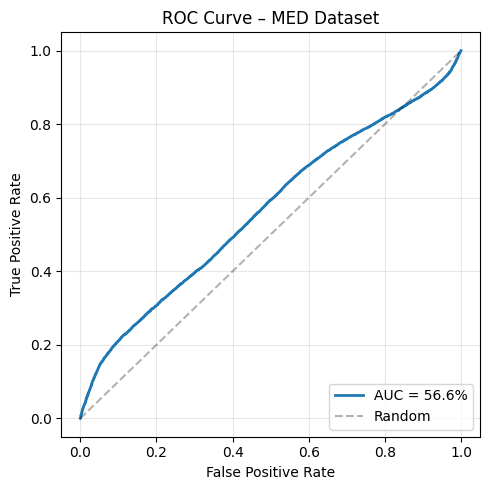

In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/med/med_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (MED): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MED Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion matrix

Soglia ottimale (Youden): 0.4223

=== METRICHE SYNTH ===
Accuracy:  61.95%
Precision: 57.88%
Recall:    22.36%
F1-Score:  32.26%

Matrice di Confusione:
[[23252  2899]
 [13832  3984]]


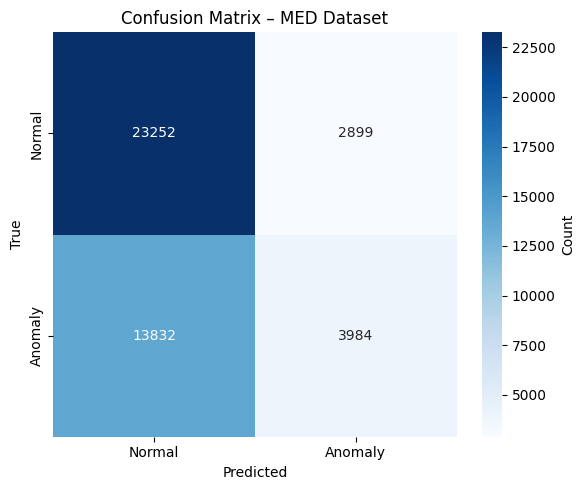


Dettagli:
True Negatives:  23252
False Positives: 2899
False Negatives: 13832
True Positives:  3984


In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_synth/med/med_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE MED ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – MED Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")